# Assemble and Assess the METBK Data

The first step in the preparation of the analysis-ready surface pCO2 data from the Endurance Array consists of the prepararion of properly prepared and cleaned Bulk Meteorolgy (METBK) sensor data; specifically the surface T/S and wind data. The current OOI system, to be blunt, makes a hash of this data and then compounds the issue by merging that poorly assembled data into the surface pCO2 data sets. This has negative implications for the calculation of the CO2 flux from the ocean to the atmosphere and for cross-comparisons with alternative data sets (e.g., co-located discrete samples or SOCAT), or for calculating other parameters of the carbonate system from estimates of total alkalinity. With the code below, we will create merged, cleaned and both 10-minute and hourly averaged METBK data sets (starting from the original 1-minute data) that can then be used in the re-processing of the surface pCO2 data into an analysis ready data product. As a side benefit, we will also have the beginnings of an analysis ready METBK data set that can be used for other purposes (e.g., calculations of bulk flux parameters via the [TOGA-COARE bulk air-sea flux algorithm](https://github.com/NOAA-PSL/COARE-algorithm)).

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
import warnings
import xarray as xr
import zarr

from gsw import SP_from_C

from ooi_data_explorations.common import get_annotations, get_deployment_dates, load_gc_thredds
from ooi_data_explorations.qartod.discrete_samples import distance_to_cast
from ooi_data_explorations.combine_data import combine_datasets
from ooi_data_explorations.uncabled.process_metbk import metbk_datalogger

from pyseas.data.generic_functions import magnetic_declination, magnetic_correction

# load local utilities
sys.path.append("../")
from utils import apply_qc_results, load_discrete, load_ndbc, metadata_reset, robust_regression, odr_regression
from examples.carbonate.METBK.metbk_metadata import METBK, ENCODINGS

# filter out some warnings
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

## Set up Local Data Directories

The code in this notebook will generate data and save it to the user's local computer. This allows for the reuse of
the data (saving time). The root path set up below, should be updated based on the user's own system and
preferences.

In [2]:
# Create root path in user's home directory
root_path = os.path.join(os.path.expanduser('~'), 'ooidata', 'carbonate')

# Create the directories if they don't exist
os.makedirs(root_path, exist_ok=True)

# test to see if we are running in a JupyterHub environment (some of this processing takes some horsepower)
IS_JUPYTERHUB = (
    'JUPYTERHUB_API_TOKEN' in os.environ or
    'JUPYTERHUB_USER' in os.environ or
    'JUPYTERHUB_BASE_URL' in os.environ
)

if not IS_JUPYTERHUB:
    print(f'Note, running some of the code below outside of a JupyterHub environment may be slow. Consider loading this notebook into a JupyterHub environment.')

Note, running some of the code below outside of a JupyterHub environment may be slow. Consider loading this notebook into a JupyterHub environment.


## Load and Prepare Co-Located Data

We'll use data from the co-located NDBC moorings and the discrete sample data collected during maintenace cruises in assessing the overall quality of the assembled METBK data records.

### Load the NDBC Buoy Data for Oregon (Station 46050, Stonewall Bank) and Washington (Station 46041, Cape Elizabeth)

In [3]:
external_path = os.path.join(root_path, 'external')  # external data sources used
os.makedirs(external_path, exist_ok=True)

#ndbc_46050 = load_ndbc('46050')  # Stonewall Bank, used for the Oregon moorings
#ndbc_46050.to_netcdf(os.path.join(external_path, 'NDBC_46050.nc'), mode='w', format='NETCDF4', engine='h5netcdf')
ndbc_46050 = xr.load_dataset(os.path.join(external_path, 'NDBC_46050.nc'), engine='h5netcdf')
#ndbc_46041 = load_ndbc('46041')  # Cape Elizabeth, used for the Washington moorings
#ndbc_46041.to_netcdf(os.path.join(external_path, 'NDBC_46041.nc'), mode='w', format='NETCDF4', engine='h5netcdf')
ndbc_46041 = xr.load_dataset(os.path.join(external_path, 'NDBC_46041.nc'), engine='h5netcdf')

# there are a couple periods of bad data in the NDBC records
m = (ndbc_46050['time'] >= pd.Timestamp('2015-04-01')) & (ndbc_46050['time'] <= pd.Timestamp('2015-04-21')) 
ndbc_46050 = ndbc_46050.where(~m, drop=True)
m = (ndbc_46041['time'] >= pd.Timestamp('2017-08-21')) & (ndbc_46041['time'] <= pd.Timestamp('2017-09-24')) 
ndbc_46041 = ndbc_46041.where(~m, drop=True)

### Load the Discrete Sample Data for Endurance

In [4]:
depth = 1.0  # Buoy subsurface sensors, depth in meters
depth_limit = 4.0  # window to use to find applicable discrete samples (depth +- depth_limit)
sample_dist = [3.0, 5.0, 3.0, 5.0]
discrete = load_discrete(depth, depth_limit)
discrete = discrete[(discrete['Start Time [UTC]'] >= pd.to_datetime('2015-04-01T00:00:00Z'))]  # Endurance 3 to the present (larger CSM's not deployed until EA3)

In [5]:
def prep_samples(ds, discrete, dist=2.5):
    """
    Find discrete samples co-located with mooring measurements in space and
    water mass.

    Uses distance between mooring and discrete sample collection locations,
    along with temperature differences between the mooring and ship CTD, to
    identify samples that are spatially proximate and from the same water
    mass. Aligns mooring measurements within a 60-minute time window and 
    filters based on temperature agreement.

    Parameters
    ----------
    ds : xarray.Dataset
        Mooring dataset containing time series of sea surface measurements
        including salinity, temperature, pCO2, and alkalinity.
    discrete : pandas.DataFrame
        Discrete sample data with CTD measurements and bottle closure times.
        Must contain 'CTD Bottle Closure Time [UTC]', 'CTD Temperature 1
        [deg C]', 'CTD Temperature 2 [deg C]', and 'Calculated Alkalinity
        [umol/kg]' columns.
    dist : float, optional
        Maximum distance threshold in kilometers (or appropriate units) for
        considering samples as co-located with the mooring. Default is 2.5.

    Returns
    -------
    pandas.DataFrame
        Filtered discrete samples with added mooring measurements
        (sea_surface_salinity, sea_surface_temperature, pco2_atm, pco2_ssw,
        alkalinity). Samples are filtered to within `dist` of the mooring,
        within 60 minutes temporally, with mooring-CTD temperature difference
        ≤0.50°C, and unreasonable alkalinity values (>2300 umol/kg) set to
        NaN.

    """    
    # find discrete sample data close to the mooring
    distance = distance_to_cast(discrete, ds['latitude'].values, ds['longitude'].values)
    samples = discrete[distance <= dist].copy()
    
    # create placeholders to add the mooring data to the discrete samples
    samples['sea_surface_salinity'] = np.nan
    samples['sea_surface_temperature'] = np.nan
    
    # vectorized alignment of mooring data with discrete samples
    ds_time_float = ds['time'].astype(float).values
    sample_times = samples['CTD Bottle Closure Time [UTC]'].values.astype(float)
    
    # convert to minutes
    dt_matrix = (ds_time_float[:, np.newaxis] - sample_times[np.newaxis, :]) / 1e9 / 60
    
    # find indices where time difference is within 60 minutes
    mask = np.abs(dt_matrix) <= 60
    
    # calculate medians for each sample
    for col, ds_var in [('sea_surface_salinity', 'sea_surface_salinity'),
                        ('sea_surface_temperature', 'sea_surface_temperature')]:
        ds_values = ds[ds_var].values
        medians = np.array([np.nanmedian(ds_values[mask[:, j]]) if mask[:, j].any() 
                           else np.nan for j in range(len(sample_times))])
        samples[col] = medians
    
    # remove records where the difference between mooring and CTD water temperature is greater than 0.50
    ctd = samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1)
    mooring = samples['sea_surface_temperature']
    samples = samples[(ctd - mooring).abs() <= 0.50]
    
    return samples

## Processing Code for the METBK

Processing code used to load and merge the different sources of METBK data, apply automated QC tests and HITL QC annotations to remove bad data, re-calculate derived parameters, and finally produce the 10-minute and hourly averaged data sets. The hourly averaged data set will be used in the PCO2A processing to calculate sea-to-air pCO<sub>2</sub> flux estimates.

In [6]:
import glob
import requests
import requests
import tempfile

from concurrent.futures import ProcessPoolExecutor
from bs4 import BeautifulSoup
from io import BytesIO

from cgsn_parsers.parsers.parse_swnd import Parser
from proc_wind import proc_wind


def process_files(file):
    """
    Process a single wind data file by parsing, converting to dataframe, and
    calculating 1-minute averages.
    
    Parameters
    ----------
    file : str
        URL or path to the ASCII wind data file to process.
    
    Returns
    -------
    xarray.Dataset or None
        Processed wind data as an xarray dataset with 1-minute averages, or None if the
        file is empty or cannot be downloaded.
    
    Notes
    -----
    This function performs the following steps:
    1. Downloads the file from URL if it's a web URL, otherwise reads from local path
    2. Loads and parses the ASCII file using the Parser
    3. Converts parsed data to a pandas DataFrame
    4. Sets time as the index after converting from Unix timestamp
    5. Calculates 1-minute averages using proc_wind
    """
    # determine if input is a URL or local path
    if file.startswith('http://') or file.startswith('https://'):
        # download the file from the URL
        try:
            response = requests.get(file, timeout=60)
            response.raise_for_status()
            
            # write content to a temporary file
            with tempfile.NamedTemporaryFile(mode='wb', delete=False, 
                                            suffix='.log') as tmp_file:
                tmp_file.write(response.content)
                tmp_path = tmp_file.name
            
            # load the file and parse the data
            swnd = Parser(tmp_path)
            swnd.load_ascii()
            swnd.parse_data()
            
            # clean up the temporary file
            os.unlink(tmp_path)
            
        except requests.exceptions.RequestException as e:
            print(f"Error downloading {file}: {e}")
            return None
        except Exception as e:
            print(f"Error processing {file}: {e}")
            if 'tmp_path' in locals():
                os.unlink(tmp_path)
            return None
    else:
        # process local file
        swnd = Parser(file)
        swnd.load_ascii()
        swnd.parse_data()
    
    # convert the parsed data to a dataframe
    raw = pd.DataFrame(swnd.data)
    if raw.empty:
        return None
        
    raw['time'] = pd.to_datetime(raw.time, unit='s')
    raw.set_index('time', drop=False, inplace=True)
    
    # calculate the 1-minute averages, converting to an xarray dataset in the process
    wind = proc_wind(raw)
    
    return wind

def raw_wind(site, deployment):
    """
    Process raw 5-second wind data for a specific site and deployment using parallel processing.
    
    Checks for the existence of raw, 5-second wind data collected during the specified
    deployment from the OOI raw data server. If found, reprocesses the data per the NDBC
    methodology to replace incorrectly calculated winds. The raw 5-second data is processed
    in parallel using concurrent.futures.ProcessPoolExecutor and converted to 1-minute
    averages.
    
    Parameters
    ----------
    site : str
        The site identifier (e.g., 'ce01issm', 'ga01sumo').
    deployment : int
        The deployment number.
    
    Returns
    -------
    xarray.Dataset or None
        Processed wind dataset containing 1-minute averaged data with the following
        variables:
        - eastward_wind: Eastward wind component
        - northward_wind: Northward wind component
        - sonic_temperature: Temperature from sonic anemometer
        Returns None if no raw wind data is found for the specified deployment.
    
    Notes
    -----
    - Fetches data from OOI raw data server at
      https://rawdata.oceanobservatories.org/files/
    - Uses ProcessPoolExecutor with 5 workers for parallel processing
    - Removes duplicate timestamps after concatenating all processed files
    - Filters out faulty values:
        * sonic_temperature <= 0 (power-on artifacts)
        * absolute eastward_wind >= 60 m/s (unrealistic values)
    - Expected data path: {SITE}/D{deployment:05d}/cg_data/dcl12/metwnd/*.log
    
    Examples
    --------
    >>> wind_data = raw_wind('ce01issm', 1)
    >>> if wind_data is not None:
    ...     print(f"Processed {len(wind_data.time)} timestamps")
    """    
    # construct the URL for the raw data server
    base_url = 'https://rawdata.oceanobservatories.org/files/'
    data_path = f'{site.upper()}/D{deployment:05d}/cg_data/dcl12/metwnd/'
    full_url = base_url + data_path
    
    # check if the directory exists and get list of .log files
    try:
        response = requests.get(full_url, timeout=30)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None
    
    # parse the directory listing to find .log files
    soup = BeautifulSoup(response.text, 'html.parser')
    log_files = [link.get('href') for link in soup.find_all('a') 
                 if link.get('href', '').endswith('.log')]
    
    if not log_files:
        return None
    
    print('Raw, 5-second wind data found. Processing in favor of the 1-minute METBK wind')
    
    # construct full URLs for each log file
    file_urls = [full_url + filename for filename in sorted(log_files)]
    
    if IS_JUPYTERHUB:
        with ProcessPoolExecutor(max_workers=5) as executor:
            frames = list(executor.map(process_files, file_urls))
    else:
        frames = [process_files(file_url) for file_url in file_urls]
        
    # concat the datasets and remove any duplicate timestamps
    frames = [x for x in frames if x is not None]
    ds = xr.concat(frames, 'time')
    _, index = np.unique(ds['time'], return_index=True)
    ds = ds.isel(time=index)
    
    # some simple clean-up (faulty values when the unit is first powered on)
    ds = ds.where(ds.sonic_temperature > 0, drop=True)
    ds = ds.where(np.abs(ds.eastward_wind) < 60, drop=True)
    
    return ds

In [7]:
from functools import partial


def process_deployment(grp, site, node, sensor, rinst, anno_logger, anno_ct, keep_vars, test_vars):
    """
    Process a single deployment group from METBK data.
    
    This function handles the complete processing pipeline for one deployment including:
    - Data cleanup and QC application
    - Precipitation rate calculation
    - CT sensor data replacement when logger data is missing
    - Conductivity despiking and salinity recomputation
    - Wind data correction for magnetic declination
    - Resampling to 10-minute and hourly averages
    
    Parameters
    ----------
    grp : tuple
        Tuple containing (deployment_number, xarray.Dataset) from groupby operation
    site : str
        OOI site designation
    node : str
        OOI node designation
    sensor : str
        OOI sensor designation
    rinst : xarray.Dataset
        Recovered instrument data from CT sensor
    anno_logger : dict
        HITL annotations for METBK logger
    anno_ct : dict
        HITL annotations for METBK-CT sensor
    keep_vars : list
        List of variable names to retain in final dataset
    test_vars : list
        List of variable names to use in QC testing
    
    Returns
    -------
    avg : xarray.Dataset
        10-minute median-averaged data for the deployment
    hourly : xarray.Dataset
        Hourly median-averaged data for the deployment
    """
    print(f'Processing deployment {grp[0]} of {int(grp[1].deployment.max().values)}') 
    # clean-up/reorganize the data
    data = metbk_datalogger(grp[1])

    # apply the QC flags and HITL annotations for the METBK logger data
    data = apply_qc_results(data, anno_logger)

    # prepare the precipation values prior to calculating rain rates
    rain = data['precipitation'].copy()
    rain_diff = rain.diff('time')  # 1st-order differences
    rain_diff = xr.concat([xr.zeros_like(rain.isel(time=0)), rain_diff], dim='time')  # prepend a leading 0

    # Filter out sensor noise (0.30 mm) and any negative values (replacing them with 0's)
    rain_diff = xr.where(rain_diff > 0.30, rain_diff, 0.0)
    
    # now reset the precipitation variable prior to summing below
    data['precipitation'] = rain_diff
    
    # catch longwave_irradiance issues missed by QARTOD
    data['longwave_irradiance'] = data['longwave_irradiance'].where(data['longwave_irradiance'] > 100)
    
    # On ocassion, the CT data in the METBK log file is missing (replaced with either a fill or stuck value).
    # Use the recovered instrument data from the CT sensor, if available, to replace the missing data so we
    # have a more complete and useful record.
    ct = rinst.where(rinst.deployment == grp[0], drop=True)
    if len(ct.time) > 0:  # if we didn't internally record, the instrument data will be missing (happened a couple of times)
        # apply the QC flags and HITL annotations for the METBK-CT data
        ct = apply_qc_results(ct, anno_ct)
    
        # create a new 1-minute, NaN-filled time record for the METBK data so we can populate all possible CT values
        start, end = get_deployment_dates(site, node, sensor, grp[0])
        trange = pd.date_range(pd.to_datetime(start[:-1]), pd.to_datetime(end[:-1]), freq='1Min')
        new_time = xr.Dataset(coords={'time': trange})
        data = data.reindex_like(new_time['time'], method='nearest', tolerance=pd.Timedelta(seconds=45))
        data['deployment'] = data['time'].astype(int) * 0 + grp[0]

        # re-index the 5-minute CT data into the new, 1-minute METBK record and use this 1-minute record to replace 
        # missing CT data in the data logger records
        ct = ct.reindex_like(new_time['time'], method='nearest', tolerance=pd.Timedelta(minutes=5))
        m = np.isnan(data['sea_surface_conductivity'])
        data['sea_surface_conductivity'][m] = ct['sea_surface_conductivity'][m]
        data['sea_surface_temperature'][m] = ct['sea_surface_temperature'][m]
        del new_time, ct, m

    # only keep the variables we are interested in using going forward
    for v in data.variables:
        if v not in keep_vars:
            data = data.drop_vars(v)

    # minimize the effects of the spikiness in the conductivity data using a cutoff value and then a series of boxcar 
    # filters; not perfect but better than any despike algorithm currently available
    data['sea_surface_conductivity'] = data['sea_surface_conductivity'].where(data['sea_surface_conductivity'] > 2.5)
    data['sea_surface_conductivity'] = data['sea_surface_conductivity'].rolling(time=7, center=True).construct("window").median("window", skipna=True)
    data['sea_surface_conductivity'] = data['sea_surface_conductivity'].rolling(time=7, center=True).construct("window").median("window", skipna=True)
    data['sea_surface_conductivity'] = data['sea_surface_conductivity'].rolling(time=11, center=True).construct("window").mean("window", skipna=True)

    # re-compute the salinity to address any cases where the surface temperature or conductivity was NaN'd due to a
    # QC test, but the derived salinity was not (in other words, propogate those NaN's)
    data['sea_surface_salinity'] = SP_from_C(data['sea_surface_conductivity'] * 10.0, data['sea_surface_temperature'], 1.0)

    # check to see if we have raw, 5-second wind data we can use instead of the METBK logged data
    wind_corr = True
    wind = raw_wind(site, grp[0])
    if wind:
        wind_corr = False
        data['eastward_wind_velocity'] = wind['eastward_wind'].reindex_like(data['time'], method='nearest', tolerance=pd.Timedelta(seconds=45))
        data['northward_wind_velocity'] = wind['northward_wind'].reindex_like(data['time'], method='nearest', tolerance=pd.Timedelta(seconds=45))
    
    # remove some anamolous wind data that should have been caught with QARTOD....
    data['eastward_wind_velocity'] = data['eastward_wind_velocity'].where(abs(data['eastward_wind_velocity']) < 60)
    data['northward_wind_velocity'] = data['northward_wind_velocity'].where(abs(data['northward_wind_velocity']) < 60)
    
    # correct the wind components for magnetic declination (note, we are dropping the wind parameters corrected by
    # OOI as they use a magnetic model now 5+ years out of date).
    theta = magnetic_declination(data.attrs['geospatial_lat_min'], data.attrs['geospatial_lon_min'], data['time'].astype(float) / 1e9)
    u, v = magnetic_correction(np.nanmean(theta), data['eastward_wind_velocity'].values, data['northward_wind_velocity'].values)
    data['eastward_wind_velocity'] = ('time', u)
    data['northward_wind_velocity'] = ('time', v)
    
    # correct the wind speeds prior to 10-minute and hourly averaging based on a correction term developed by 
    # Dr. James Edson (personal communication, December 2025)
    data['wind_speed'] = (data['eastward_wind_velocity']**2 + data['northward_wind_velocity']**2)**0.5
    if wind_corr:
        data['wind_speed'] = 1.1236 * data['wind_speed']
        wind_direction = np.arctan2(data['eastward_wind_velocity'], data['northward_wind_velocity'])  # reported in radians
        wind_direction = np.where(wind_direction < 0, wind_direction + np.pi * 2, wind_direction)  # 0 to 360 degrees, still in radians
        data['eastward_wind_velocity'] = data['wind_speed'] * np.sin(wind_direction)
        data['northward_wind_velocity'] = data['wind_speed'] * np.cos(wind_direction)
        del wind_direction
    
    # resample the data into 10-minute, median-averaged records
    rsmpl = data.copy()  # create a temporary copy of the data
    rsmpl['time'] = rsmpl['time'] + pd.Timedelta(seconds=300)  # shift the time record by 5 minutes to center the data on the 10-minute mark
    avg = rsmpl.resample(time='10Min', skipna=True).median(dim='time', keep_attrs=True)  # bin the data into hourly bins
    
    # calculate the hourly precipitation rate for the 10-minute data
    avg['precipitation'] = rsmpl['precipitation'].resample(time='10Min', skipna=True).sum(dim='time', keep_attrs=True) * 6
    avg['precipitation'] = avg['precipitation'].where(avg['precipitation'] < 250)
    
    # fill in any gaps less than 30-minutes via linear interploation, dropping records where there was no data
    avg = avg.interpolate_na(dim='time', max_gap='30 minutes')   # fill gaps 30 minutes long or less
    avg = avg.where(~np.isnan(avg.deployment), drop=True)  # drop any remaining fill values
    del rsmpl
    
    # use the vector averaged wind components and the scalar averaged wind speed to recalculate the wind vectors (NDBC methodology)
    wind_direction = np.arctan2(avg['eastward_wind_velocity'], avg['northward_wind_velocity'])  # reported in radians
    wind_direction = np.where(wind_direction < 0, wind_direction + np.pi * 2, wind_direction)  # 0 to 360 degrees, still in radians
    avg['eastward_wind_velocity'] = avg['wind_speed'] * np.sin(wind_direction)
    avg['northward_wind_velocity'] = avg['wind_speed'] * np.cos(wind_direction)

    # now that we have re-computed the wind components, drop the wind speed and the wind direction
    avg = avg.drop_vars('wind_speed')        
    del wind_direction
    
    # if all of the parameters of interest are NaNs for a particular point in time, remove that row
    m = xr.DataArray(~np.all([np.isnan(avg[v]) for v in test_vars], axis=0), coords={'time': avg['time']})
    avg = avg.where(m, drop=True)
    
    # add the 10-minute averaged data to the deployments list
    avg['deployment'] = avg['deployment'].astype(int)
    
    # resample the data into hourly, median-averaged records
    data['time'] = data['time'] + pd.Timedelta(minutes=30)  # shift the time record by 30 minutes to center the data at the top of the hour after resampling
    hourly = data.resample(time='1H', skipna=True).median(dim='time', keep_attrs=True)  # bin the data into hourly bins
    
    # calculate the hourly precipitation rate
    hourly['precipitation'] = data['precipitation'].resample(time='1H', skipna=True).sum(dim='time', keep_attrs=True)
    hourly['precipitation'] = hourly['precipitation'].where(hourly['precipitation'] < 250)

    # fill in any gaps less than 3-hours via linear interploation, dropping records where there was no data
    hourly = hourly.interpolate_na(dim='time', max_gap='3H')        # fill gaps 3 hours long or less
    hourly = hourly.where(~np.isnan(hourly.deployment), drop=True)  # drop any remaining fill values
    del data
    
    # use the vector averaged wind components and the scalar averaged wind speed to recalculate the wind vectors (NDBC methodology)
    wind_direction = np.arctan2(hourly['eastward_wind_velocity'], hourly['northward_wind_velocity'])  # reported in radians
    wind_direction = np.where(wind_direction < 0, wind_direction + np.pi * 2, wind_direction)  # 0 to 360 degrees, still in radians
    hourly['eastward_wind_velocity'] = hourly['wind_speed'] * np.sin(wind_direction)
    hourly['northward_wind_velocity'] = hourly['wind_speed'] * np.cos(wind_direction)

    # now that we have re-computed the wind components, drop the wind speed and the wind direction
    hourly = hourly.drop_vars('wind_speed')        
    del wind_direction
    
    # if all of the parameters of interest are NaNs for a particular point in time, remove that row
    m = xr.DataArray(~np.all([np.isnan(hourly[v]) for v in test_vars], axis=0), coords={'time': hourly['time']})
    hourly = hourly.where(m, drop=True)
    
    # add the hourly averaged data to the deployments list
    hourly['deployment'] = hourly['deployment'].astype(int)
    
    return avg, hourly


def load_metbk(site, node, sensor):
    """
    Load and process METBK (Bulk Meteorology) data from OOI data files.
    
    This function loads telemetered and recovered host data from a METBK data logger,
    combines them with recovered instrument data from a CT sensor, applies QC tests,
    and resamples the data into 10-minute and hourly averaged datasets. Processing
    is performed in parallel across deployments using multiprocessing with up to 5
    worker processes.
    
    The processing pipeline includes:
    - Loading and combining telemetered and recovered host data
    - Removing invalid QC variables
    - Processing each deployment in parallel:
        * Applying QC flags and HITL annotations
        * Calculating precipitation rates
        * Replacing missing CT data with recovered instrument data
        * Despiking conductivity measurements
        * Correcting wind data for magnetic declination
        * Resampling to 10-minute and hourly averages
    - Concatenating all deployments into final datasets
    
    Parameters
    ----------
    site : str
        OOI site designation (e.g., 'CE02SHSM')
    node : str
        OOI node designation (e.g., 'SBD11')
    sensor : str
        OOI sensor designation (e.g., '06-METBKA000')
    
    Returns
    -------
    ds_10min : xarray.Dataset
        10-minute median-averaged data for all deployments, sorted by deployment and time.
        Contains meteorological and oceanographic variables including:
        - barometric_pressure
        - precipitation (as hourly rate in mm/hr)
        - relative_humidity
        - air_temperature
        - longwave_irradiance
        - shortwave_irradiance
        - sea_surface_temperature
        - sea_surface_conductivity
        - sea_surface_salinity
        - eastward_wind_velocity (corrected for magnetic declination)
        - northward_wind_velocity (corrected for magnetic declination)
    
    ds_hourly : xarray.Dataset
        Hourly median-averaged data for all deployments with the same variables as ds_10min.
    
    Notes
    -----
    - Uses multiprocessing with 5 worker processes for parallel deployment processing
    - Wind velocities are corrected for magnetic declination using time-varying models
    - Conductivity data is despiked using rolling median and mean filters
    - Gaps up to 30 minutes (10-min data) or 3 hours (hourly data) are filled via interpolation
    - Requires the following helper functions to be available at module level:
        * metbk_datalogger, apply_qc_results, get_deployment_dates, SP_from_C
        * raw_wind, magnetic_declination, magnetic_correction
        * get_annotations, load_kdata, combine_datasets
    
    Examples
    --------
    >>> ds_10min, ds_hourly = load_metbk('CE02SHSM', 'SBD11', '06-METBKA000')
    """
    tag = r'.*METBK.*\.nc$'  # file globbing tag to select the METBK NetCDF files from the local kdata directory

    # create a list of the METBK variables we are going to keep
    keep_vars = ['deployment', 'time', 'barometric_pressure', 'precipitation', 'relative_humidity', 'air_temperature', 'longwave_irradiance',
                 'shortwave_irradiance', 'sea_surface_temperature', 'sea_surface_conductivity', 'sea_surface_salinity', 
                 'eastward_wind_velocity', 'northward_wind_velocity']

    # create a list of the METBK variables we will use in QC testing
    test_vars = ['barometric_pressure', 'relative_humidity', 'air_temperature', 'longwave_irradiance',
                 'shortwave_irradiance', 'sea_surface_temperature', 'sea_surface_conductivity', 'sea_surface_salinity', 
                 'eastward_wind_velocity', 'northward_wind_velocity']

    # grab any HITL annotations set for the METBK logger
    anno_logger = get_annotations(site, node, sensor)
    anno_ct = get_annotations(site, node, '06-METBKA001')
    
    # load the telemetered and recovered_host data sets recorded by the data logger
    telem = load_gc_thredds(site, node, sensor, 'telemetered', 'metbk_a_dcl_instrument', tag)
    rhost = load_gc_thredds(site, node, sensor, 'recovered_host', 'metbk_a_dcl_instrument_recovered', tag)
    
    # load the recovered surface CT sensor (SBE 37-SM MicroCAT) instrument data
    rinst = load_gc_thredds(site, node, '06-METBKA001', 'recovered_inst', 'metbk_ct_instrument', tag)
        
    # combine the telemetered and recovered_host data, but don't apply any averaging
    ds = combine_datasets(telem, rhost, None, None)
    ds = ds.reset_coords()
    del telem, rhost
    
    # remove the precipitation QC variables as they incorrectly flag data
    ds = ds.drop_vars(['precipitation_qartod_executed', 'precipitation_qartod_results'])

    # also remove the automated QC test results for the CT measurements as we are going to handle that data separately
    ds = ds.drop_vars(['sea_surface_conductivity_qartod_executed', 'sea_surface_conductivity_qartod_results',
                       'sea_surface_temperature_qartod_executed', 'sea_surface_temperature_qartod_results'])

    # grouping the data by deployment, clean up/reorganize the records, apply the QC tests and resample
    grps = list(ds.groupby('deployment'))
    
    # Create a partial function with the fixed arguments
    process_func = partial(
        process_deployment,
        site=site,
        node=node,
        sensor=sensor,
        rinst=rinst,
        anno_logger=anno_logger,
        anno_ct=anno_ct,
        keep_vars=keep_vars,
        test_vars=test_vars
    )
    
    if IS_JUPYTERHUB:
        # process up to 5 deployments at a time via a multiprocessing pool
        with ProcessPoolExecutor(max_workers=5) as executor:
            results = list(executor.map(process_func, grps))
    else:
        # process each deployment sequentially
        results = [process_func(grp) for grp in grps]
        
    # Separate the 10-minute and hourly results
    deploy_10min = [r[0] for r in results if r[0] is not None]
    deploy_hourly = [r[1] for r in results if r[1] is not None]
        
    # concatenate the resampled data back into single datasets
    deployments = [i for i in deploy_10min if i]  # remove any empty deployments
    ds_10min = xr.concat(deployments, 'time')
    ds_10min = ds_10min.sortby(['deployment', 'time'])

    deployments = [i for i in deploy_hourly if i]  # remove any empty deployments
    ds_hourly = xr.concat(deployments, 'time')
    ds_hourly = ds_hourly.sortby(['deployment', 'time'])
   
    return ds_10min, ds_hourly

## Load the METBK Data

In [8]:
%%time
# set up the directory to save the METBK data
metbk_path = os.path.join(root_path, 'METBK')
os.makedirs(metbk_path, exist_ok=True)

# load the METBK data from the Endurance Array Surface Moorings
sites = ['CE02SHSM', 'CE04OSSM', 'CE07SHSM', 'CE09OSSM']
node = 'SBD11'
sensor = '06-METBKA000'
met = []
for i, site in enumerate(sites):
    # load the data for each site, node, sensor combination
    #met10, metbk = load_metbk(site, node, sensor)
    
    # save the re-combined, averaged data for future analysis
    #out10 = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.10minute.per_deployment.nc')
    #met10 = met10.where(met10.time <= np.datetime64('2025-12-15T23:59:59.999Z'), drop=True)
    #met10 = metadata_reset(met10, site, node, sensor, [0.0, 0.0, 0.0], METBK)
    #met10.to_netcdf(out10, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)
    
    outfile = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.hourly.per_deployment.nc')
    #metbk = metbk.where(metbk.time <= np.datetime64('2025-12-15T23:59:59.999Z'), drop=True)
    #metbk = metadata_reset(metbk, site, node, sensor, [0.0, 0.0, 0.0], METBK)
    #metbk.to_netcdf(outfile, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)

    # prepare the data for further reviews in this notebook (use the hourly data)
    metbk = xr.load_dataset(outfile, engine='h5netcdf')
    met.append(metbk)

CPU times: total: 188 ms
Wall time: 194 ms


## Evaluating the METBK Data

Timeseries plots of the METBK data (T/S and wind parameters only) that will be subsequently used in the PCO2A processing. Use these plots to review the data for any issues or problems. Note, this is an iterative process. There may be issues in the `load_metbk` script above that need to be addressed, or an annotation needs to be created to flag the data as bad in order to exclude it from further analysis. Address the errors and re-run the reviews by using the widget tools to zoom in/out of the data and to pan through time. Focus on overlapping deployments, discrete samples and potentially stuck (METBK logger repeating last value received) values.

For each of the plots, data from the co-located NDBC buoy is shown in light grey, discrete samples are shown as points (data from the ship's CTD) or stars (data from discrete bottle samples). Data is color coded by deployment to help visualize differences (if any) between overlapping deployments). Variables plotted are the sea surface temperature and salinity, the estimated total alkalinity and the eastward and northward wind components.

Note, for reasons I have not been able to figure out yet, sometimes the plot is created but the display is blank. Go ahead and run all 4 plotting sections and then hit F5 to refresh the page. This is a new "feature".

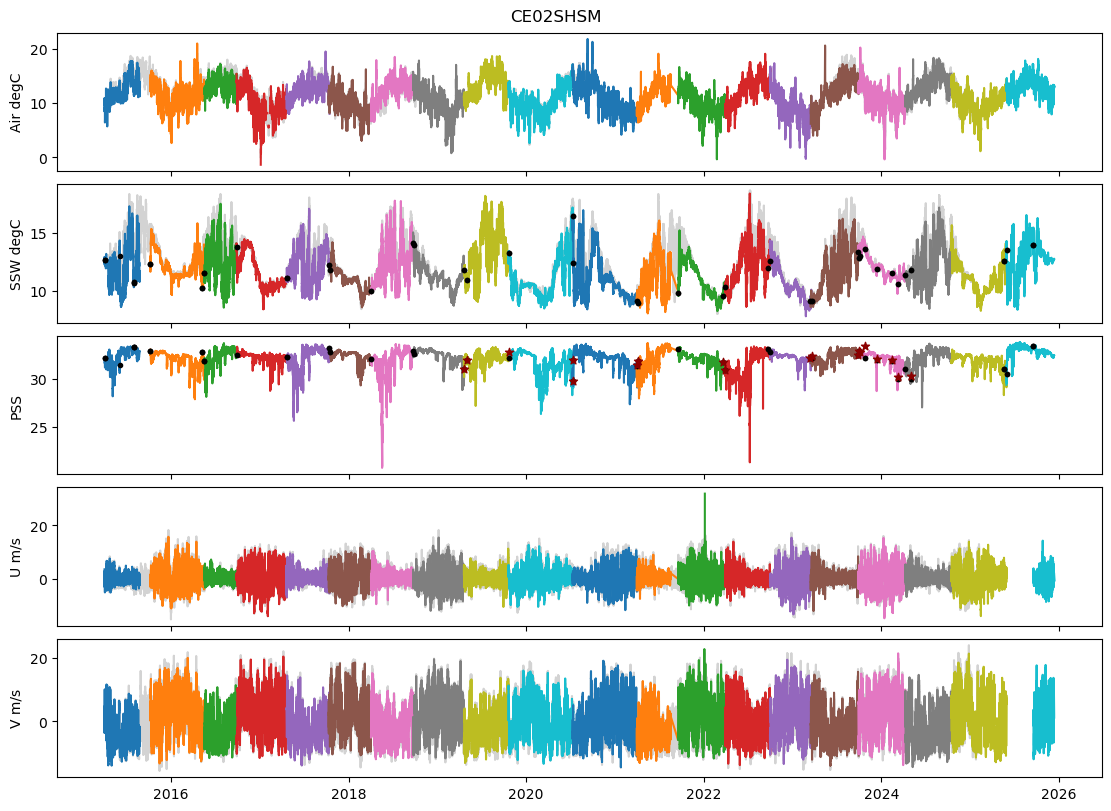

In [11]:
# select the moooring of interest
indx = 0  # CE02SHSM

# subselect the relevant discrete samples
samples = prep_samples(met[indx], discrete, sample_dist[indx])

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='Air degC')
ax1.set(ylabel='SSW degC')
ax2.set(ylabel='PSS')
ax3.set(ylabel='U m/s')
ax4.set(ylabel='V m/s')

# plot the NDBC data
ax0.plot(ndbc_46050['time'], ndbc_46050['atmp'], label='46050', color='LightGrey')
ax1.plot(ndbc_46050['time'], ndbc_46050['wtmp'], label='46050', color='LightGrey')
ax3.plot(ndbc_46050['time'], ndbc_46050['wspu'], label='46050', color='LightGrey')
ax4.plot(ndbc_46050['time'], ndbc_46050['wspv'], label='46050', color='LightGrey')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.air_temperature, label='Air')
    ax1.plot(data.time, data.sea_surface_temperature, label='SSW')
    ax2.plot(data.time, data.sea_surface_salinity, label='PSU')
    ax3.plot(data.time, data.eastward_wind_velocity, label='East')
    ax4.plot(data.time, data.northward_wind_velocity, label='North')
    
# plot the discrete sample data
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='DarkRed', zorder=10)

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)

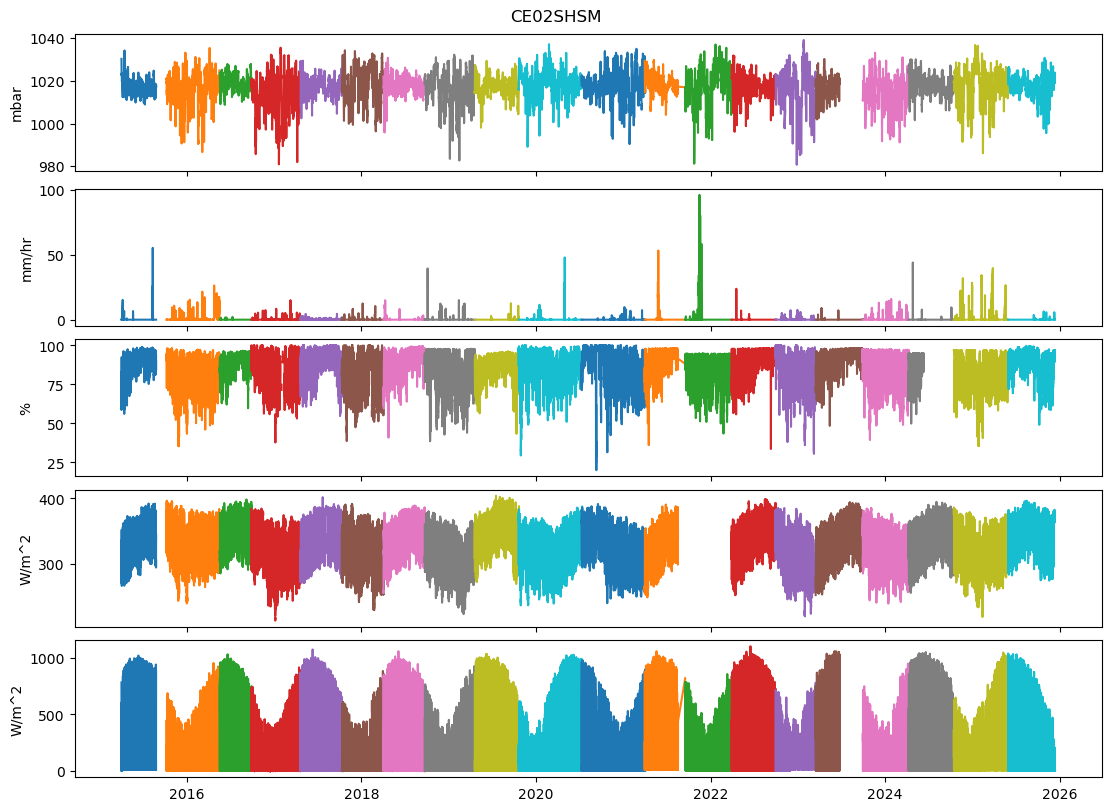

In [12]:
# select the moooring of interest
indx = 0  # CE02SHSM

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='mbar')
ax1.set(ylabel='mm/hr')
ax2.set(ylabel='%')
ax3.set(ylabel='W/m^2')
ax4.set(ylabel='W/m^2')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.barometric_pressure, label='mbar')
    ax1.plot(data.time, data.precipitation, label='mm/hr')
    ax2.plot(data.time, data.relative_humidity, label='Percent')
    ax3.plot(data.time, data.longwave_irradiance, label='PSS')
    ax4.plot(data.time, data.shortwave_irradiance, label='degC')

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)    

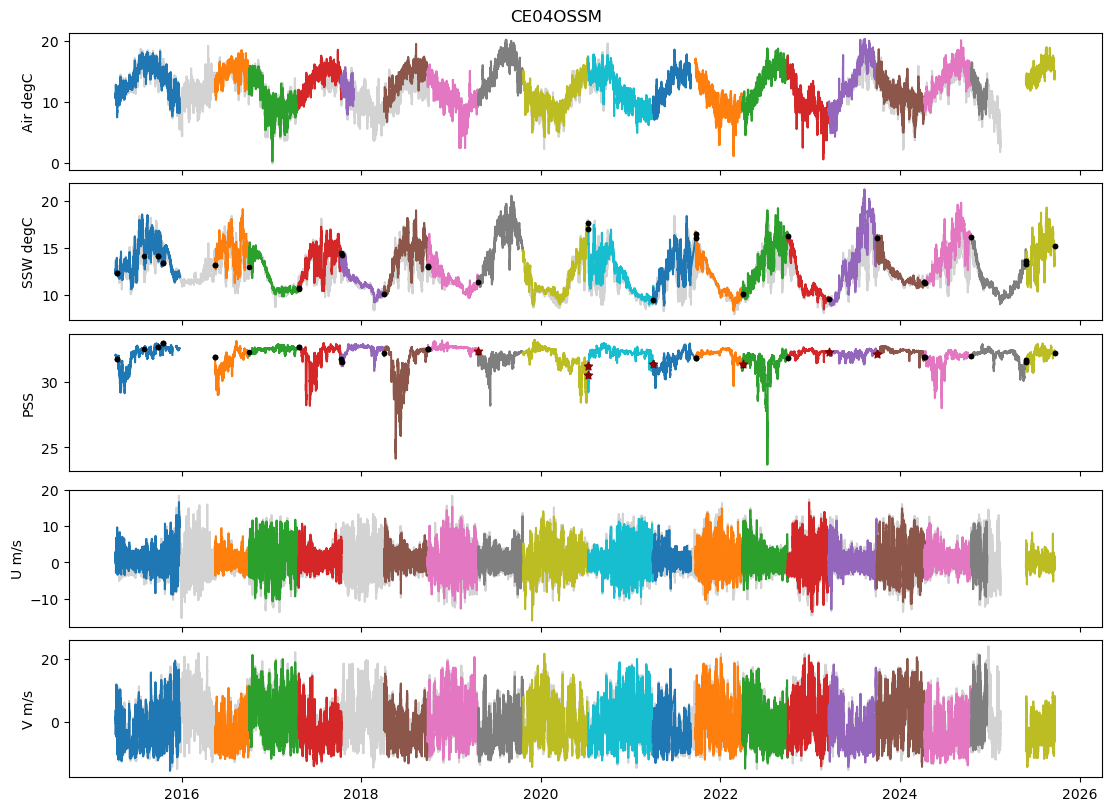

In [13]:
# select the moooring of interest
indx = 1  # CE04OSSM

# subselect the relevant discrete samples
samples = prep_samples(met[indx], discrete, sample_dist[indx])

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='Air degC')
ax1.set(ylabel='SSW degC')
ax2.set(ylabel='PSS')
ax3.set(ylabel='U m/s')
ax4.set(ylabel='V m/s')

# plot the NDBC data
ax0.plot(ndbc_46050['time'], ndbc_46050['atmp'], label='46050', color='LightGrey')
ax1.plot(ndbc_46050['time'], ndbc_46050['wtmp'], label='46050', color='LightGrey')
ax3.plot(ndbc_46050['time'], ndbc_46050['wspu'], label='46050', color='LightGrey')
ax4.plot(ndbc_46050['time'], ndbc_46050['wspv'], label='46050', color='LightGrey')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.air_temperature, label='Air')
    ax1.plot(data.time, data.sea_surface_temperature, label='SSW')
    ax2.plot(data.time, data.sea_surface_salinity, label='PSU')
    ax3.plot(data.time, data.eastward_wind_velocity, label='East')
    ax4.plot(data.time, data.northward_wind_velocity, label='North')
    
# plot the discrete sample data
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='DarkRed', zorder=10)

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)

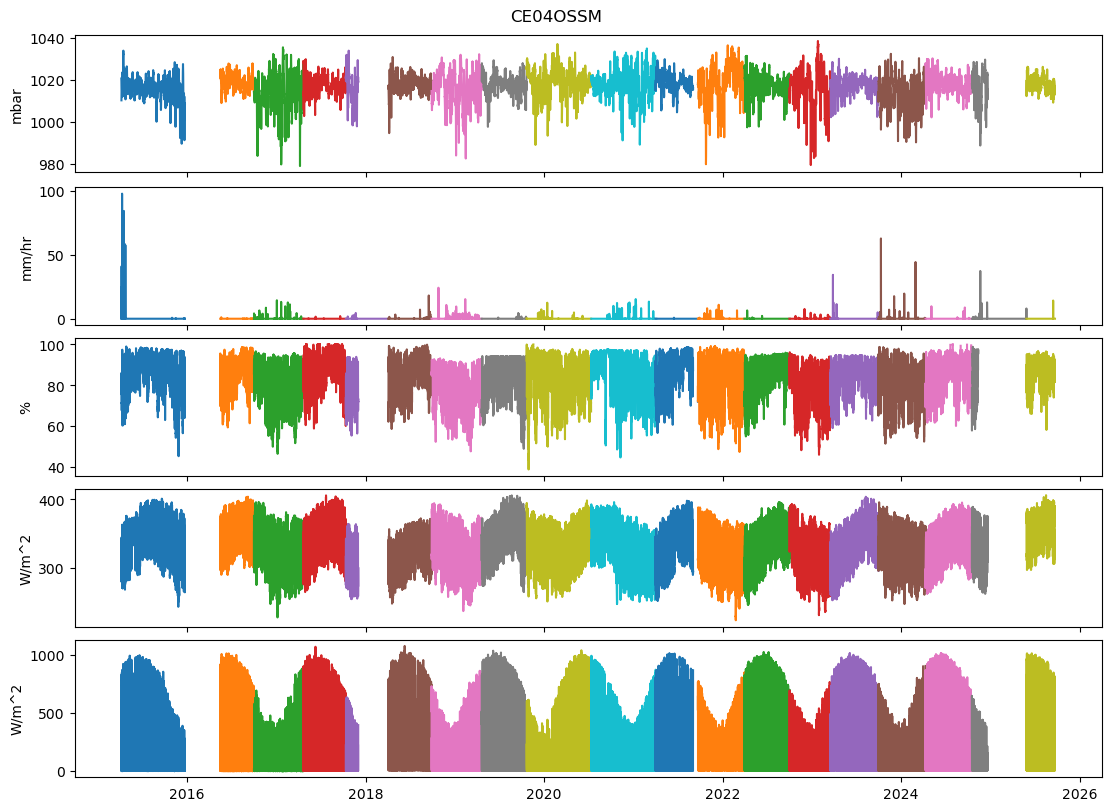

In [14]:
# select the moooring of interest
indx = 1  # CE04OSSM

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='mbar')
ax1.set(ylabel='mm/hr')
ax2.set(ylabel='%')
ax3.set(ylabel='W/m^2')
ax4.set(ylabel='W/m^2')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.barometric_pressure, label='mbar')
    ax1.plot(data.time, data.precipitation, label='mm/hr')
    ax2.plot(data.time, data.relative_humidity, label='Percent')
    ax3.plot(data.time, data.longwave_irradiance, label='PSS')
    ax4.plot(data.time, data.shortwave_irradiance, label='degC')

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)    

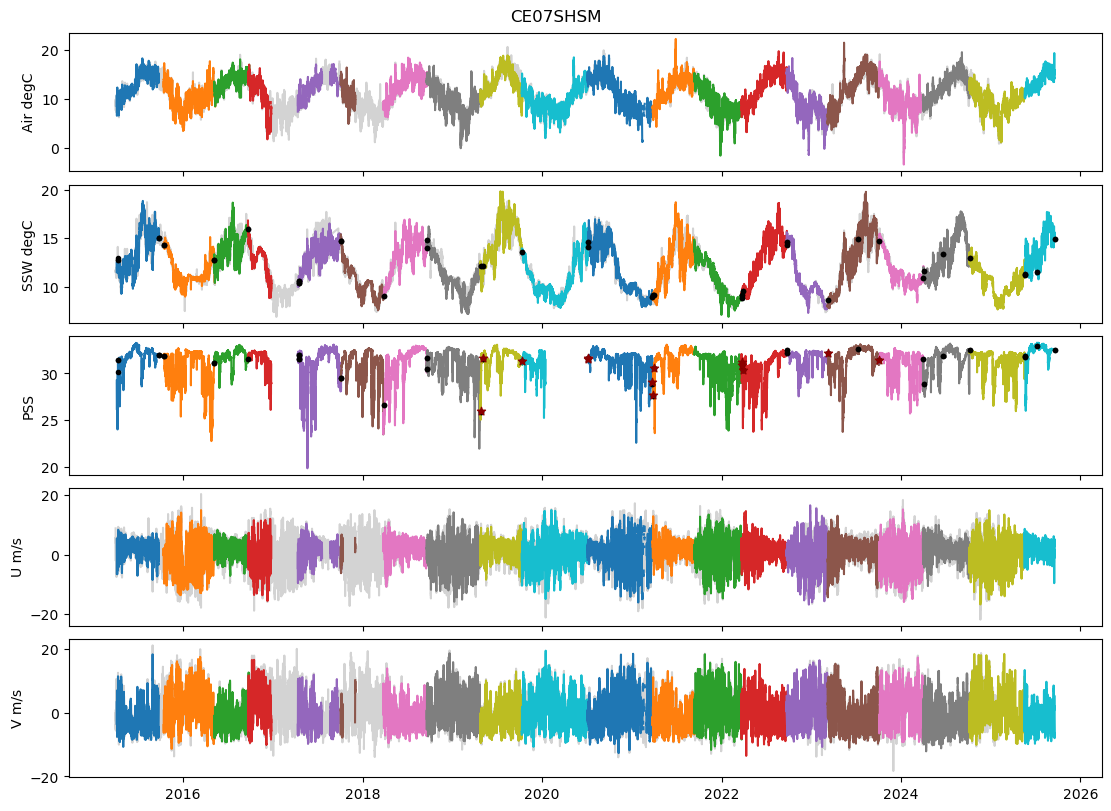

In [15]:
# select the moooring of interest
indx = 2  # CE07SHSM

# subselect the relevant discrete samples
samples = prep_samples(met[indx], discrete, sample_dist[indx])

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='Air degC')
ax1.set(ylabel='SSW degC')
ax2.set(ylabel='PSS')
ax3.set(ylabel='U m/s')
ax4.set(ylabel='V m/s')

# plot the NDBC data
ax0.plot(ndbc_46041['time'], ndbc_46041['atmp'], label='46050', color='LightGrey')
ax1.plot(ndbc_46041['time'], ndbc_46041['wtmp'], label='46050', color='LightGrey')
ax3.plot(ndbc_46041['time'], ndbc_46041['wspu'], label='46050', color='LightGrey')
ax4.plot(ndbc_46041['time'], ndbc_46041['wspv'], label='46050', color='LightGrey')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.air_temperature, label='Air')
    ax1.plot(data.time, data.sea_surface_temperature, label='SSW')
    ax2.plot(data.time, data.sea_surface_salinity, label='PSU')
    ax3.plot(data.time, data.eastward_wind_velocity, label='East')
    ax4.plot(data.time, data.northward_wind_velocity, label='North')
    
# plot the discrete sample data
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='DarkRed', zorder=10)

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)

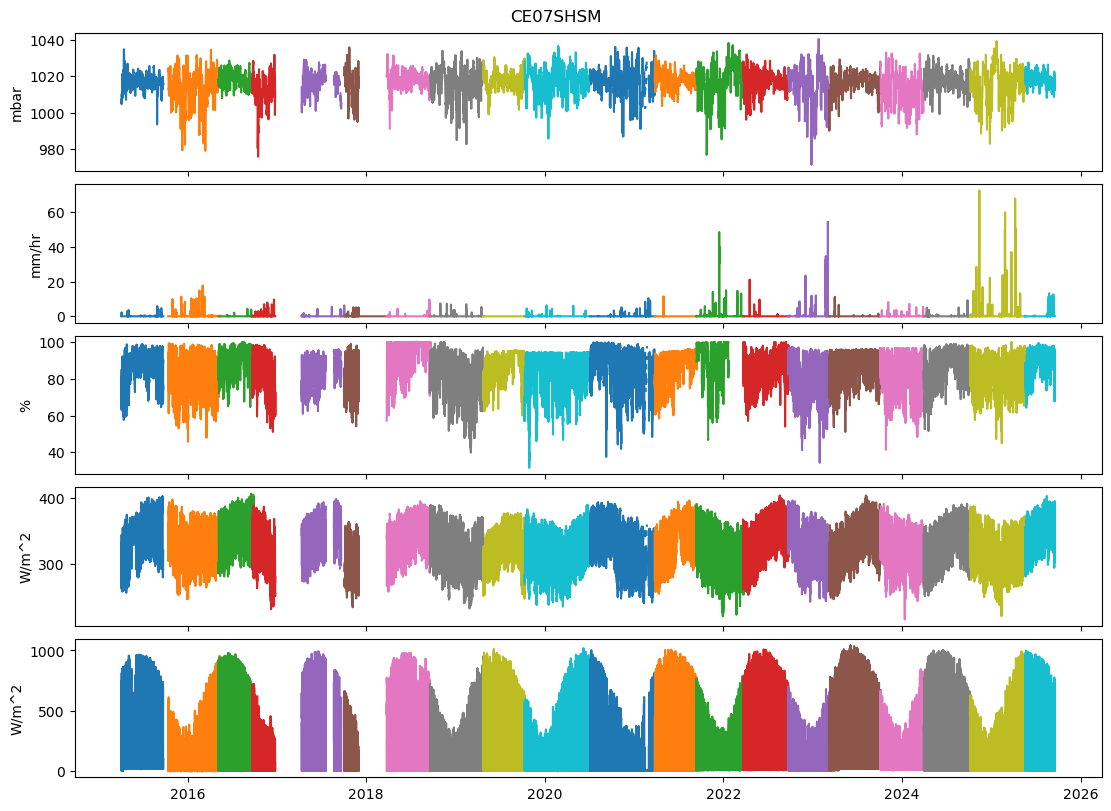

In [16]:
# select the moooring of interest
indx = 2  # CE07SHSM

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='mbar')
ax1.set(ylabel='mm/hr')
ax2.set(ylabel='%')
ax3.set(ylabel='W/m^2')
ax4.set(ylabel='W/m^2')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.barometric_pressure, label='mbar')
    ax1.plot(data.time, data.precipitation, label='mm/hr')
    ax2.plot(data.time, data.relative_humidity, label='Percent')
    ax3.plot(data.time, data.longwave_irradiance, label='PSS')
    ax4.plot(data.time, data.shortwave_irradiance, label='degC')

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)    

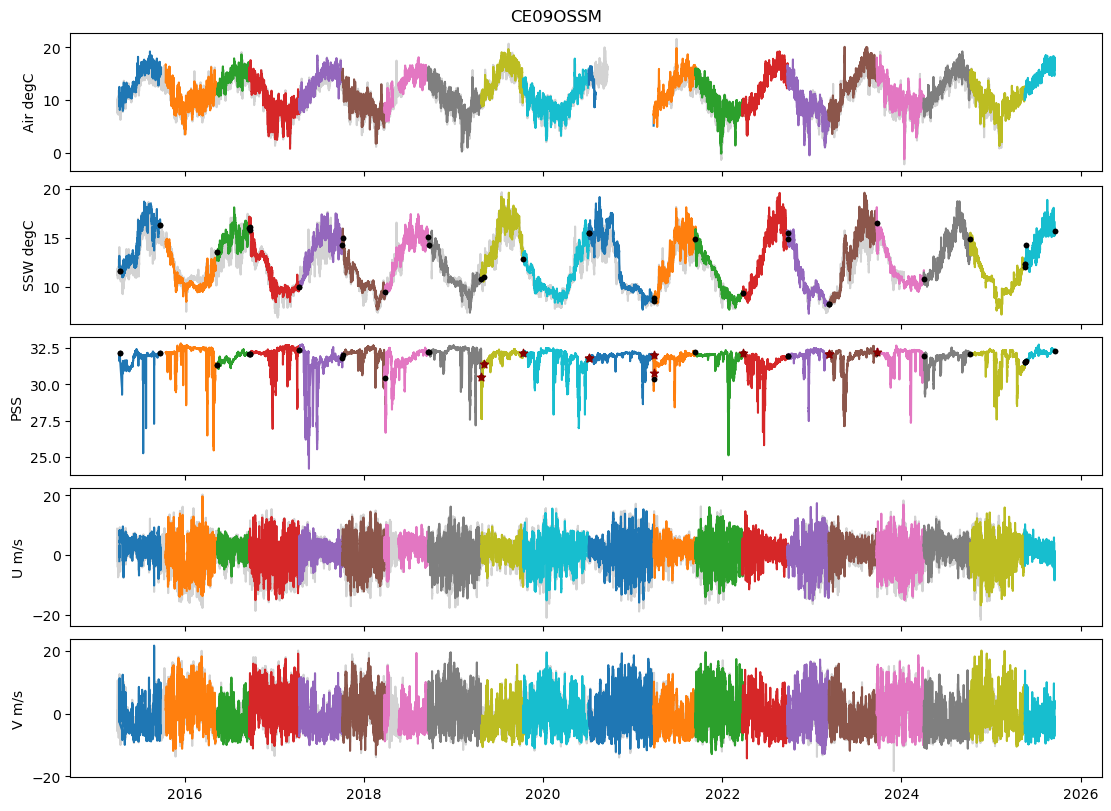

In [17]:
# select the moooring of interest
indx = 3  # CE09OSSM

# subselect the relevant discrete samples
samples = prep_samples(met[indx], discrete, sample_dist[indx])

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='Air degC')
ax1.set(ylabel='SSW degC')
ax2.set(ylabel='PSS')
ax3.set(ylabel='U m/s')
ax4.set(ylabel='V m/s')

# plot the NDBC data
ax0.plot(ndbc_46041['time'], ndbc_46041['atmp'], label='46050', color='LightGrey')
ax1.plot(ndbc_46041['time'], ndbc_46041['wtmp'], label='46050', color='LightGrey')
ax3.plot(ndbc_46041['time'], ndbc_46041['wspu'], label='46050', color='LightGrey')
ax4.plot(ndbc_46041['time'], ndbc_46041['wspv'], label='46050', color='LightGrey')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.air_temperature, label='Air')
    ax1.plot(data.time, data.sea_surface_temperature, label='SSW')
    ax2.plot(data.time, data.sea_surface_salinity, label='PSU')
    ax3.plot(data.time, data.eastward_wind_velocity, label='East')
    ax4.plot(data.time, data.northward_wind_velocity, label='North')
    
# plot the discrete sample data
ax1.scatter(samples['Start Time [UTC]'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', label='CTD', color='Black', zorder=10)
ax2.scatter(samples['Start Time [UTC]'], samples['Discrete Salinity [psu]'], marker='*', label='Discrete', color='DarkRed', zorder=10)

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)

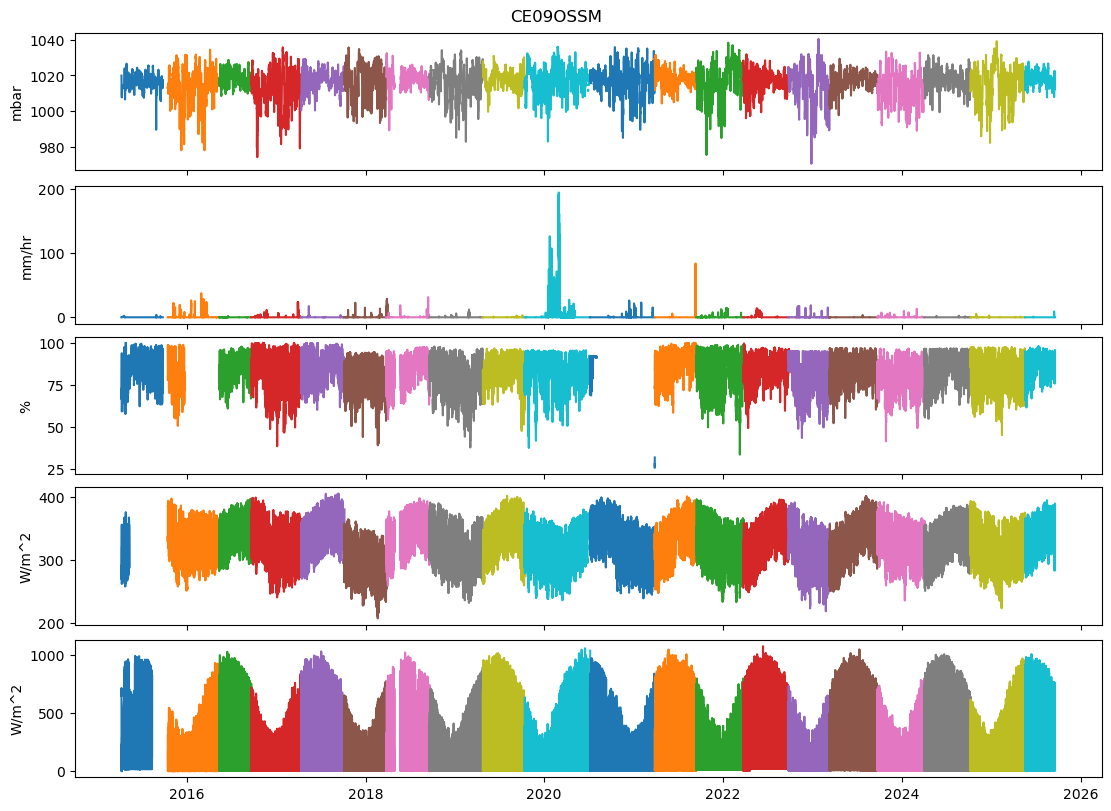

In [18]:
# select the moooring of interest
indx = 3  # CE09OSSM

# set up the plotting figure
fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(11, 8), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle(sites[indx])
ax0, ax1, ax2, ax3, ax4 = axes.flatten()

# set the plot to interactive and label the y-axes
plt.ion()
ax0.set(ylabel='mbar')
ax1.set(ylabel='mm/hr')
ax2.set(ylabel='%')
ax3.set(ylabel='W/m^2')
ax4.set(ylabel='W/m^2')

# plot the METBK data grouped by deployment (helps to see the overlaps)
grps = list(met[indx].groupby('deployment'))
for grp in grps:  # plot data by deployment
    data = grp[1].copy()
    ax0.plot(data.time, data.barometric_pressure, label='mbar')
    ax1.plot(data.time, data.precipitation, label='mm/hr')
    ax2.plot(data.time, data.relative_humidity, label='Percent')
    ax3.plot(data.time, data.longwave_irradiance, label='PSS')
    ax4.plot(data.time, data.shortwave_irradiance, label='degC')

fig.canvas.draw()
fig.canvas.flush_events()
#plt.show()
display(fig)    

## Continuous Timeseries (and Zarr ZipStore)

Convert the data to continuous timeseries, merging overlapping deployment data, and create both NetCDF and Zarr ZipStore files of the continuous records.

In [19]:
%%time
# reset the hourly data to continuous records (no overlapping deployments) and save the results to both NetCDF and a Zarr ZipStore
for i, site in enumerate(sites):
    # create a continuous, monotonic time record (no deployment overlaps)
    data = met[i].copy()
    remove = ['longitude', 'latitude', 'depth', 'station_name']
    data = data.drop_vars(remove)
    data = data.groupby('time').mean(skipna=True)
    data = metadata_reset(data, site, node, sensor, [0.0, 0.0, 0.0], METBK)
    data = data.drop_vars('deployment')
    
    # save the continuous data for future analysis
    nc_file = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.hourly.continuous.nc')
    data.to_netcdf(nc_file, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)

    # Create a Zarr ZipStore
    zip_file = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.hourly.continuous.zarr.zip')
    with zarr.storage.ZipStore(zip_file, mode="w") as store:
        # Write the Xarray Dataset to the ZipStore
        data.to_zarr(store=store, encoding=ENCODINGS)

    met[i] = data.copy()

    # load the 10-minute data and create the same files
    nc_file = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.10minute.per_deployment.nc')
    data = xr.load_dataset(outfile, engine='h5netcdf')
    remove = ['longitude', 'latitude', 'depth', 'station_name']
    data = data.drop_vars(remove)
    data = data.groupby('time').mean(skipna=True)
    data = metadata_reset(data, site, node, sensor, [0.0, 0.0, 0.0], METBK)
    data = data.drop_vars('deployment')
    
    # save the continuous data for future analysis
    nc_file = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.10minute.continuous.nc')
    data.to_netcdf(nc_file, mode='w', format='NETCDF4', engine='h5netcdf', encoding=ENCODINGS)

    # Create a Zarr ZipStore
    zip_file = os.path.join(metbk_path, '-'.join([site, node, sensor]) + '.10minute.continuous.zarr.zip')
    with zarr.storage.ZipStore(zip_file, mode="w") as store:
        # Write the Xarray Dataset to the ZipStore
        data.to_zarr(store=store, encoding=ENCODINGS)    

CPU times: total: 30.2 s
Wall time: 15 s


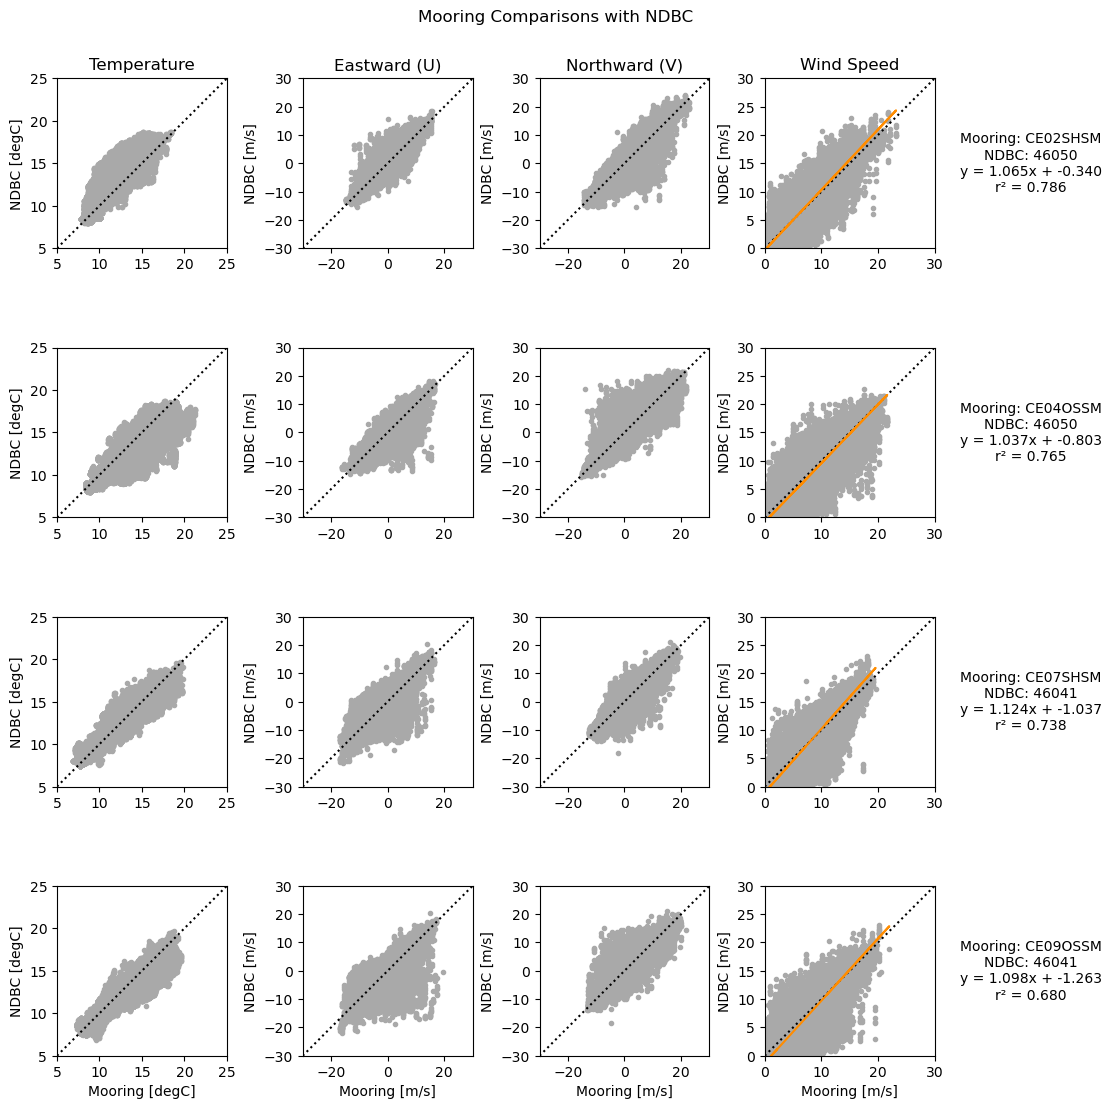

In [20]:
fig, axes = plt.subplots(nrows=4, ncols=4, squeeze=True, figsize=(11, 11), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle('Mooring Comparisons with NDBC')

# set up the subplots (axis limits, titles and labels)
for i in [0, 1, 2, 3]:
    # set up the axis limits and titles
    axes[i, 0].set(aspect='equal', xlim=[5, 25], ylim=[5, 25], ylabel='NDBC [degC]')
    axes[i, 1].set(aspect='equal', xlim=[-30, 30], ylim=[-30, 30], ylabel='NDBC [m/s]')
    axes[i, 2].set(aspect='equal', xlim=[-30, 30], ylim=[-30, 30], ylabel='NDBC [m/s]')
    axes[i, 3].set(aspect='equal', xlim=[0, 30], ylim=[0, 30], ylabel='NDBC [m/s]')

    # create the 1:1 line plots
    axes[i, 0].plot(np.arange(5, 26), np.arange(5, 26), ':', color='Black')
    axes[i, 1].plot(np.arange(-30, 31), np.arange(-30, 31), ':', color='Black')
    axes[i, 2].plot(np.arange(-30, 31), np.arange(-30, 31), ':', color='Black')
    axes[i, 3].plot(np.arange(0, 31), np.arange(0, 31), ':', color='Black')
    
axes[0, 0].set(title='Temperature')
axes[3, 0].set(xlabel='Mooring [degC]')
axes[0, 1].set(title='Eastward (U)')
axes[3, 1].set(xlabel='Mooring [m/s]')
axes[0, 2].set(title='Northward (V)')
axes[3, 2].set(xlabel='Mooring [m/s]')
axes[0, 3].set(title='Wind Speed')
axes[3, 3].set(xlabel='Mooring [m/s]')

# fill in the subplots
for i, data in enumerate(met):
    if i <= 1:
        ndbc = ndbc_46050.copy()
        ndbc_str = '46050'
    else:
        ndbc = ndbc_46041.copy()
        ndbc_str = '46041'

    mooring = data.reindex_like(ndbc['time'], 'nearest', tolerance=pd.Timedelta(minutes=60))
    mooring = mooring.where(np.abs(mooring['eastward_wind_velocity']) < 20)
    axes[i, 0].scatter(mooring['sea_surface_temperature'], ndbc['wtmp'], marker='.', color='DarkGrey')
    #regr = odr_regression(mooring['sea_surface_temperature'].values, ndbc['wtmp'].values, iqr=False)
    #y = regr.beta[1] * mooring['sea_surface_temperature'].values + regr.beta[0]
    #axes[i, 0].plot(mooring['sea_surface_temperature'], y, '-', color='DarkOrange')

    axes[i, 1].scatter(mooring['eastward_wind_velocity'], ndbc['wspu'], marker='.', color='DarkGrey')
    #regr = odr_regression(mooring['eastward_wind_velocity'].values, ndbc['wspu'].values)
    #y = regr.beta[1] * mooring['eastward_wind_velocity'].values + regr.beta[0]
    #axes[i, 1].plot(mooring['eastward_wind_velocity'], y, '-', color='DarkOrange')

    axes[i, 2].scatter(mooring['northward_wind_velocity'], ndbc['wspv'], marker='.', color='DarkGrey')
    #regr = odr_regression(mooring['northward_wind_velocity'].values, ndbc['wspv'].values)
    #y = regr.beta[1] * mooring['northward_wind_velocity'].values + regr.beta[0]
    #axes[i, 2].plot(mooring['northward_wind_velocity'].values, y, '-', color='DarkOrange')

    mooring['wind_speed'] = np.sqrt(mooring['eastward_wind_velocity']**2 + mooring['northward_wind_velocity']**2)
    ndbc['wind_speed'] = np.sqrt(ndbc['wspu']**2 + ndbc['wspv']**2)
    axes[i, 3].scatter(mooring['wind_speed'], ndbc['wind_speed'], marker='.', color='DarkGrey')
    x = mooring['wind_speed'].values
    y = ndbc['wind_speed'].values
    m = np.isnan(x) | np.isnan(y)
    regr = odr_regression(x, y)
    pred = regr.beta[1] * x[~m] + regr.beta[0]
    r_sqrd = 1. - (np.var(y[~m] - pred) / np.var(y[~m]))
    axes[i, 3].plot(x[~m], pred, '-', color='DarkOrange')
    axes[i, 3].text(47, 15, f'Mooring: {sites[i]}\nNDBC: {ndbc_str}\ny = {regr.beta[1]:.3f}x + {regr.beta[0]:.3f}\nr\u00b2 = {r_sqrd:.3f}', ha='center', va='center');

display(fig)

### Cross-Comparisons: Discrete

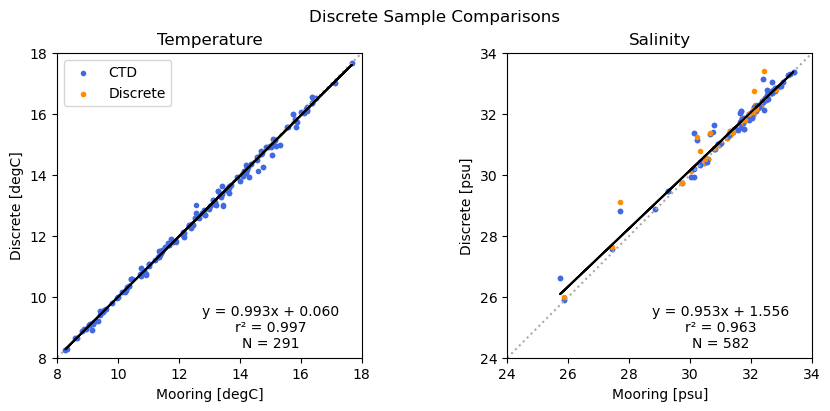

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, squeeze=True, figsize=(9, 4), constrained_layout=True)
fig.canvas.header_visible = False
fig.suptitle('Discrete Sample Comparisons')

# create the 1:1 lines
axes[0].plot(np.arange(5, 21), np.arange(5, 21), ':', color='DarkGrey')
axes[1].plot(np.arange(24, 36), np.arange(24, 36), ':', color='DarkGrey')

# list to hold the discrete sample data
full = []
for i, data in enumerate(met):
    # locate the samples that correspond to the mooring
    samples = prep_samples(data, discrete, dist=sample_dist[i])
    full.append(samples)  # append to the list for later stats

    # plot the temperature, salinity and alkalinity
    axes[0].scatter(samples['sea_surface_temperature'], samples[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1), marker='.', color='RoyalBlue', label='CTD')
    axes[1].scatter(samples['sea_surface_salinity'], samples[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1), marker='.', color='RoyalBlue', label='CTD')
    axes[1].scatter(samples['sea_surface_salinity'], samples['Discrete Salinity [psu]'], marker='.', color='DarkOrange', label='Discrete')

# convert the list of samples to a pandas dataframe
full = pd.concat(full, ignore_index=True)

# temperature regression and plot finalizing
axes[0].set(aspect='equal', xlim=[8, 18], ylim=[8, 18], title='Temperature', xlabel='Mooring [degC]', ylabel='Discrete [degC]')
handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend(handles[:2], labels[:2])
x = full['sea_surface_temperature'].values
y = full[['CTD Temperature 1 [deg C]', 'CTD Temperature 2 [deg C]']].mean(axis=1, skipna=True).values
m = np.isnan(x) | np.isnan(y)
regr = odr_regression(x, y)
pred = regr.beta[1] * x[~m] + regr.beta[0]
r_sqrd = 1. - (np.var(y[~m] - pred) / np.var(y[~m]))
axes[0].plot(x[~m], pred, '-', color='black')
axes[0].text(15, 9, f'y = {regr.beta[1]:.3f}x + {regr.beta[0]:.3f}\nr\u00b2 = {r_sqrd:.3f}\nN = {len(~m)}', horizontalalignment='center', verticalalignment='center');

# salinity regression and plot finalizing
axes[1].set(aspect='equal', xlim=[24, 34], ylim=[24, 34], title='Salinity', xlabel='Mooring [psu]', ylabel='Discrete [psu]')
x = np.concat((full['sea_surface_salinity'].values, full['sea_surface_salinity'].values))
y = np.concat((full[['CTD Salinity 1 [psu]', 'CTD Salinity 2 [psu]']].mean(axis=1, skipna=True).values, full['Discrete Salinity [psu]'].values))
m = np.isnan(x) | np.isnan(y)
regr = odr_regression(x, y)
pred = regr.beta[1] * x[~m] + regr.beta[0]
r_sqrd = 1. - (np.var(y[~m] - pred) / np.var(y[~m]))
axes[1].plot(x[~m], pred, '-', color='black')
axes[1].text(31, 25, f'y = {regr.beta[1]:.3f}x + {regr.beta[0]:.3f}\nr\u00b2 = {r_sqrd:.3f}\nN = {len(~m)}', horizontalalignment='center', verticalalignment='center');

display(fig)